In [ ]:
import re
import string
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
#import nltk

#nltk.download('punkt')
#nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/guilherme/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/guilherme/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [67]:
import spacy

nlp = spacy.load("pt_core_news_sm")

# def lematizar_texto(tokens):
#     doc = nlp(" ".join(tokens))
#     return [token.lemma_ for token in doc]

def spacy_text(text):
    doc = nlp(text)

    tokens = []

    for token in doc:
        if not token.is_stop and len(token.text) > 2:
            tokens.append(token.lemma_)
    return tokens

In [68]:
def limpar_e_preparar_dados(caminhos_ficheiros):
    """
    Lê os ficheiros, remove pontuação, converte para minúsculas 
    e tokeniza em frases/palavras.
    """
    sentencas_processadas = []
    #stop_words = set(stopwords.words('portuguese'))

    translator = str.maketrans('', '', string.punctuation)
    
    for caminho in caminhos_ficheiros:
        try:    
            print(f"A processar: {caminho}...")
            with open(caminho, 'r', encoding='utf-8') as f:
                for linha in f:
                    # 1. Limpeza básica e remoção de números/pontuação
                    linha = linha.strip().lower()
                    linha = re.sub(r"\d+", "", linha)
                    linha = linha.translate(translator)
                    
                    tokens = spacy_text(linha)
                    if tokens:
                        sentencas_processadas.append(tokens)
                     

                    # 2. Tokenização (dividir em palavras)
                    # tokens = word_tokenize(linha)

                    # 3. Eliminar StopWords
                    # stopWRemove = [w for w in tokens if w not in stop_words and len(w) > 2]

                    # 4. Lemmatize
                    #if stopWRemove:
                        #final_clean_text = lematizar_texto(stopWRemove)                    
                        #sentencas_processadas.append(final_clean_text)
                        
        except FileNotFoundError:
            print(f"Erro: O ficheiro {caminho} não foi encontardo.")
        except Exception as e:
            print(f"Aviso: Ocorreu um erro: {e}"+
                  f"\nO ficheiro {caminho} não foi encontrado.")
        

    return sentencas_processadas

In [ ]:
meus_ficheiros = ['livros/Harry Potter e A Pedra Filosofal.txt', 'livros/Harry_Potter_Camara_Secreta-br.txt'
                  , 'livros/harry_potter_e_o_calice_de_fogo-J._K._Rowling.txt','livros/harry_potter_e_o_enigma_do_principe-J._K._Rowling.txt',
                  'livros/J.K.Rowling-5-Harry_Potter_e_a_Ordem_da_Fenix.txt', 'livros/J.K.Rowling-7-Harry_Potter_e_As_Reliquias_da_Morte.txt'] 

dados_treino = limpar_e_preparar_dados(meus_ficheiros)

A processar: livros/Harry Potter e A Pedra Filosofal.txt...
A processar: livros/Harry_Potter_Camara_Secreta-br.txt...
A processar: livros/harry_potter_e_o_calice_de_fogo-J._K._Rowling.txt...
A processar: livros/harry_potter_e_o_enigma_do_principe-J._K._Rowling.txt...
A processar: livros/J.K.Rowling-5-Harry_Potter_e_a_Ordem_da_Fenix.txt...
A processar: livros/J.K.Rowling-7-Harry_Potter_e_As_Reliquias_da_Morte.txt...
Treinando modelo com 62890 frases...


In [144]:
if not dados_treino:
    print("Erro: Não foram encontrados dados para treinar o modelo.")
else:
    print(f"A treinar o modelo com {len(dados_treino)} frases...")
    
    phrases = Phrases(dados_treino, min_count=5, threshold=5)
    bigram_model = Phraser(phrases)
    dados_com_bigramas = list(bigram_model[dados_treino])

    # Trigramas
    trigram_phrases = Phrases(dados_com_bigramas, min_count=3, threshold=5)
    trigram_transform = Phraser(trigram_phrases)
    dados_finais = list(trigram_transform[dados_com_bigramas])

    model = Word2Vec(
        sentences=dados_finais,
        vector_size=150,
        epochs=100, 
        window=10, 
        min_count=5, 
        workers=3,
        sg=1
    )

    model_name = "models/my_model_word2vec.model"
    model.save(model_name)

A treinar o modelo com 62890 frases...


In [ ]:
#load do modelo
model = Word2Vec.load(model_name)

In [145]:
from gensim.models import Word2Vec

print("\n\n_________________Welcome to Harry Potter Books analysis__________________\n\n")
words = ['harry', 'quadribol', 'feitiço']

def analysis(model):
    print("_____________________1ª Fase - Teste de Most Similar_____________________\n")
    
    for word in words:
        print(f"Teste de similaridade da palavra '{word}'")
        try:
            for token, score in model.wv.most_similar(word, topn=5):
                print(f"{word.capitalize()} : Token: {token} -> {score:.4f}")
        except KeyError as e:
            print(f"Error: {e} -> A palavra {word} não foi encontrada")
        print("\n")

analysis(model)



_________________Welcome to Harry Potter Books analysis__________________


_____________________1ª Fase - Teste de Most Similar_____________________

Teste de similaridade da palavra 'harry'
Harry : Token: rony -> 0.6423
Harry : Token: olhar -> 0.5668
Harry : Token: dizer -> 0.5664
Harry : Token: correr_proteger_gritar_forte -> 0.5356
Harry : Token: tentar_manter_controle_pular -> 0.5354


Teste de similaridade da palavra 'quadribol'
Quadribol : Token: sentir_empolgado -> 0.4875
Quadribol : Token: dever_apresentar -> 0.4875
Quadribol : Token: voltar_escola_significar -> 0.4760
Quadribol : Token: decreto_estar -> 0.4729
Quadribol : Token: querer_voltar_hogwarts -> 0.4685


Teste de similaridade da palavra 'feitiço'
Feitiço : Token: feitiã§os -> 0.5156
Feitiço : Token: levicorpus -> 0.4796
Feitiço : Token: feitiã§o -> 0.4765
Feitiço : Token: contrafeitiço -> 0.4623
Feitiço : Token: lancar -> 0.4585




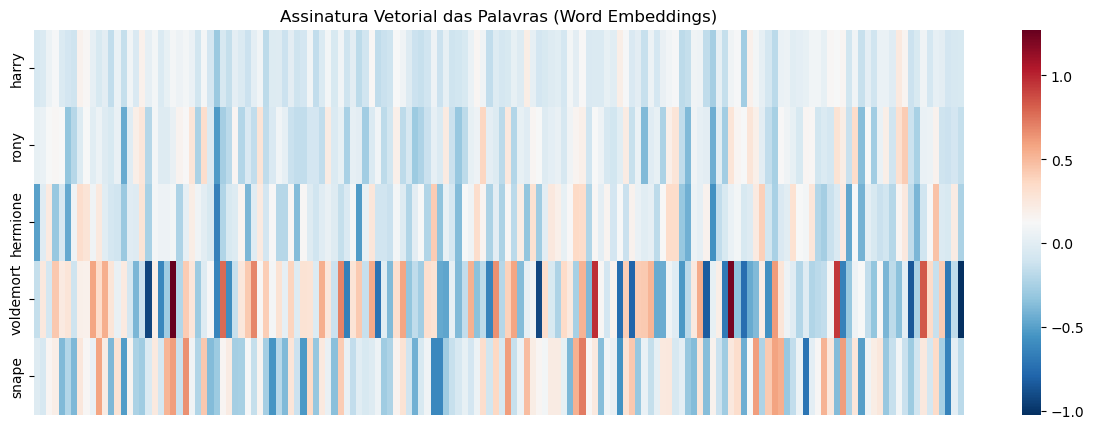

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_vetores_estilo_heatmap(model, lista_palavras):
    dados_vetores = [model.wv[p] for p in lista_palavras]

    df = pd.DataFrame(dados_vetores, index=lista_palavras)
    
    plt.figure(figsize=(15, 5))
    sns.heatmap(df, cmap='RdBu_r', cbar=True, yticklabels=True, xticklabels=False)
    
    plt.title("Assinatura Vetorial das Palavras (Word Embeddings)")
    plt.show()

plot_vetores_estilo_heatmap(model, ['harry', 'rony', 'hermione', 'voldemort', 'snape'])

In [153]:
words = ['harry', 'voldemort']

def my_similarity(model):
    print("_____________________2ª Fase - Teste da Similaridade_____________________\n")
    try:
        first = words[0]
        second = words[1]
        result = model.wv.similarity(first, second)
        print(f"A similariade entre a palavra {first} e {second} é: {result:.4f}")
    except KeyError as e:
        print(f"Error: {e} -> Uma ou mais palavras não foram encontradas")

my_similarity(model)

_____________________2ª Fase - Teste da Similaridade_____________________

A similariade entre a palavra harry e voldemort é: 0.2444


In [148]:

def Analogies(model, a,b,c):
    print("_____________________3ª Fase - Teste da Analogia_____________________\n")
    
    try:
        print(model.wv.most_similar(positive=[b,c], negative=[a], topn=30))
    except KeyError as e:
        print(f"Error: {e} -> Uma ou mais das palavras selecionadas não foram encontradas.")

Analogies(model, 'dumbledore', 'bom', 'voldemort')

_____________________3ª Fase - Teste da Analogia_____________________

[('auxiliar', 0.3220340609550476), ('feitiço_proteção', 0.3147490620613098), ('perfeitamente', 0.30986493825912476), ('precisar_de ela', 0.3042586147785187), ('sala_comunal_sonserina', 0.3041496276855469), ('stico', 0.30179932713508606), ('cuidadoso', 0.299692839384079), ('enfrentar', 0.29233554005622864), ('influência', 0.28535762429237366), ('nervoso', 0.28434616327285767), ('cometer', 0.2832365334033966), ('reprimir', 0.27932363748550415), ('corderoso', 0.27745068073272705), ('Pedro', 0.2750522494316101), ('verar', 0.27353793382644653), ('arruinar', 0.2727881669998169), ('justo', 0.27208057045936584), ('resmungar', 0.2718687951564789), ('olho_amarelo', 0.26785802841186523), ('roubar_horcrux', 0.2647175192832947), ('secar', 0.2642306089401245), ('querer_aprender', 0.2632560729980469), ('ouvilo', 0.26314398646354675), ('alcançálo', 0.2627544701099396), ('asqueroso', 0.2621976137161255), ('presumo', 0.26213243603706

In [149]:
group = ['harry', 'rony', 'hermione', 'voldemort']

def Anomalia(model):
    print("_____________________4ª Fase - Teste da Anomalia_____________________\n")
    
    result = model.wv.doesnt_match(group)
    print(f"O intruso no grupo {group} é: {result}")   

Anomalia(model)

_____________________4ª Fase - Teste da Anomalia_____________________

O intruso no grupo ['harry', 'rony', 'hermione', 'voldemort'] é: voldemort


In [150]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def display_pca_scatterplot(model, words=None):
    valid_words = [w for w in words if w in model.wv]
    
    print(f"Palavras encontradas: {len(valid_words)} de {len(words)}")
    
    if len(valid_words) < 3:
        print("Erro: Precisas de pelo menos 3 palavras válidas para gerar o gráfico!")
        return

    word_vectors = np.array([model.wv[w] for w in valid_words])

    twodim = PCA().fit_transform(word_vectors)[:,:2]

    plt.figure(figsize=(10, 8))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='red', s=100)
    
    for word, (x,y) in zip(valid_words, twodim):
        plt.text(x + 0.01, y + 0.01, word, fontsize=12)
        
    plt.title("Mapa Semântico")
    plt.show()

Palavras encontradas: 8 de 8


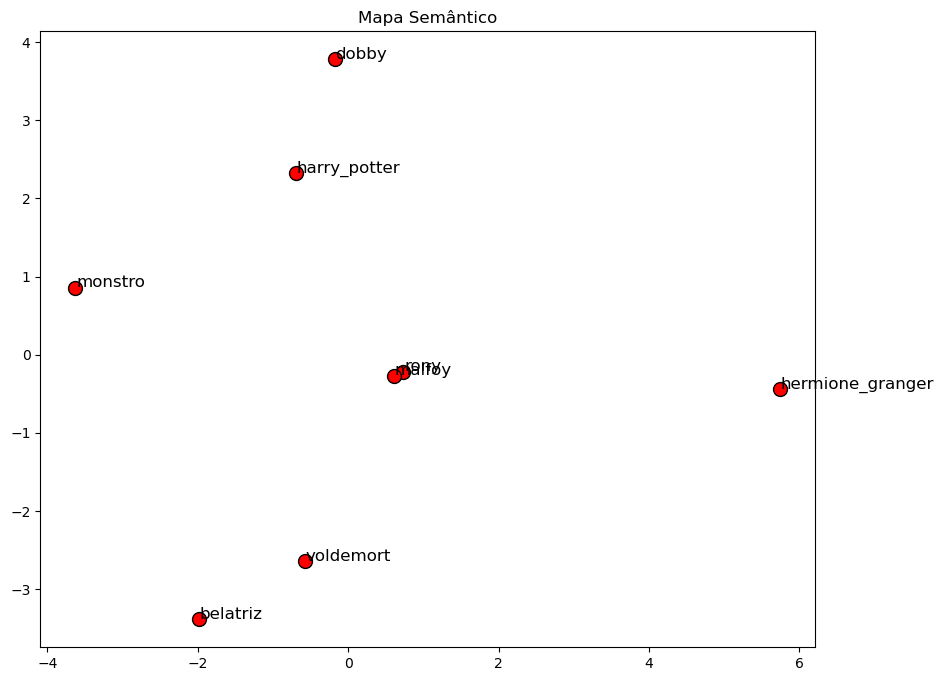

In [ ]:
words = [
    'harry_potter', 'rony', 'hermione_granger',
    'voldemort', 'belatriz', 'malfoy',
    'dobby', 'monstro'
]
display_pca_scatterplot(model,words)

In [176]:
import io

out_v = io.open('Project_models/model_harry_tensor.tsv', 'w', encoding='utf-8')
out_m = io.open('Project_models/model_harry_metadata.tsv', 'w', encoding='utf-8')

for word in model.wv.index_to_key:
    out_m.write(word + "\n")
    vector = model.wv[word]
    out_v.write('\t'.join([str(x) for x in vector]) + "\n")

out_v.close()
out_m.close()

print("Ficheiros gerados com sucesso: model_harry_tensor.tsv e model_harry_metadata.tsv")

Ficheiros gerados com sucesso: model_harry_tensor.tsv e model_harry_metadata.tsv
